In [34]:
import pandas as pd
import pickle
import sys
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from src.config import DATA_PRO, MODELS_DIR
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, silhouette_score)
import seaborn as sns
import matplotlib.pyplot as plt
sys.path.append('../')
from src.config import DATA_RAW, MODELS_DIR
import src.features.text_features
from sklearn.preprocessing import label_binarize

In [35]:
df_jobs = pd.read_csv(DATA_PRO / 'clustered_jobs.csv')
mod = pickle.load(open(MODELS_DIR / 'recommender.pkl', 'rb'))

In [36]:
sample_resume = """
Software Engineer with 3 years of experience. 
Highly skilled in Python, Django, REST APIs, and Machine Learning. 
Familiar with Agile methodologies and AWS cloud deployments.
"""
resume_vec = mod['tfidf'].transform([sample_resume])
sims = cosine_similarity(resume_vec, mod['vecs']).flatten()
top_idx = sims.argsort()[-5:][::-1]
matches = df_jobs.iloc[top_idx].copy()
matches['similarity_score'] = sims[top_idx]

print("Top 5 Job Recommendations based on Cosine Similarity:")
display(matches[['title', 'company', 'location', 'similarity_score']])

Top 5 Job Recommendations based on Cosine Similarity:


,title,company,location,similarity_score
613,Developer,Tata Consultancy Services,"New York, NY",0.304860
5052,Machine Learning Engineer/Python Developer,Red Oak Technologies,"Austin, Texas Metropolitan Area",0.302746
4712,Sr. Python Developer,GTECH LLC,"Texas, United States",0.278750
3789,Python Developer (Locals only),Thoughtwave Software and Solutions,"Chicago, IL",0.275735
1236,Senior Software Engineer (Python / Django),"Haptik, Inc","Bengaluru/Bangalore , Bengaluru / Bangalore , ...",0.269452


In [37]:
FIGURES_DIR = Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(DATA_RAW / 'resumes_clean.csv')
df['clean'] = clean_text(df['text'])
tfidf = pickle.load(open(MODELS_DIR / 'tfidf_vectorizer.pkl', 'rb'))
clf = pickle.load(open(MODELS_DIR / 'classifier.pkl', 'rb'))
X_vec = tfidf.transform(df['clean'])
y_pred = clf.predict(X_vec)
print(classification_report(df['Category'], y_pred))

                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00        20
                     Arts       1.00      1.00      1.00        36
       Automation Testing       0.96      1.00      0.98        26
               Blockchain       1.00      1.00      1.00        40
         Business Analyst       1.00      1.00      1.00        28
           Civil Engineer       1.00      1.00      1.00        24
             Data Science       1.00      1.00      1.00        40
                 Database       1.00      1.00      1.00        33
          DevOps Engineer       1.00      0.96      0.98        55
         DotNet Developer       0.97      1.00      0.98        28
            ETL Developer       1.00      1.00      1.00        40
   Electrical Engineering       1.00      1.00      1.00        30
                       HR       1.00      1.00      1.00        44
                   Hadoop       1.00      1.00      1.00     

In [38]:
X = tfidf.transform(src.features.text_features.clean_text(df['text']))
y_true = df['Category']
y_pred = clf.predict(X)
y_prob = clf.predict_proba(X)
y_bin = label_binarize(y_true, classes=clf.classes_)
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_bin, y_prob, average='weighted', multi_class='ovr'):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

Accuracy:  0.9979
Precision: 0.9980
Recall:    0.9979
F1-Score:  0.9979
ROC-AUC:   1.0000

Confusion Matrix:
 [[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0 36  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0 40  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0 28  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0 24  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0 40  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0 33  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  1  0  0  0  0  0 53  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0 28  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0 40  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0

Saved confusion matrix to E:\smarthire\reports\figures


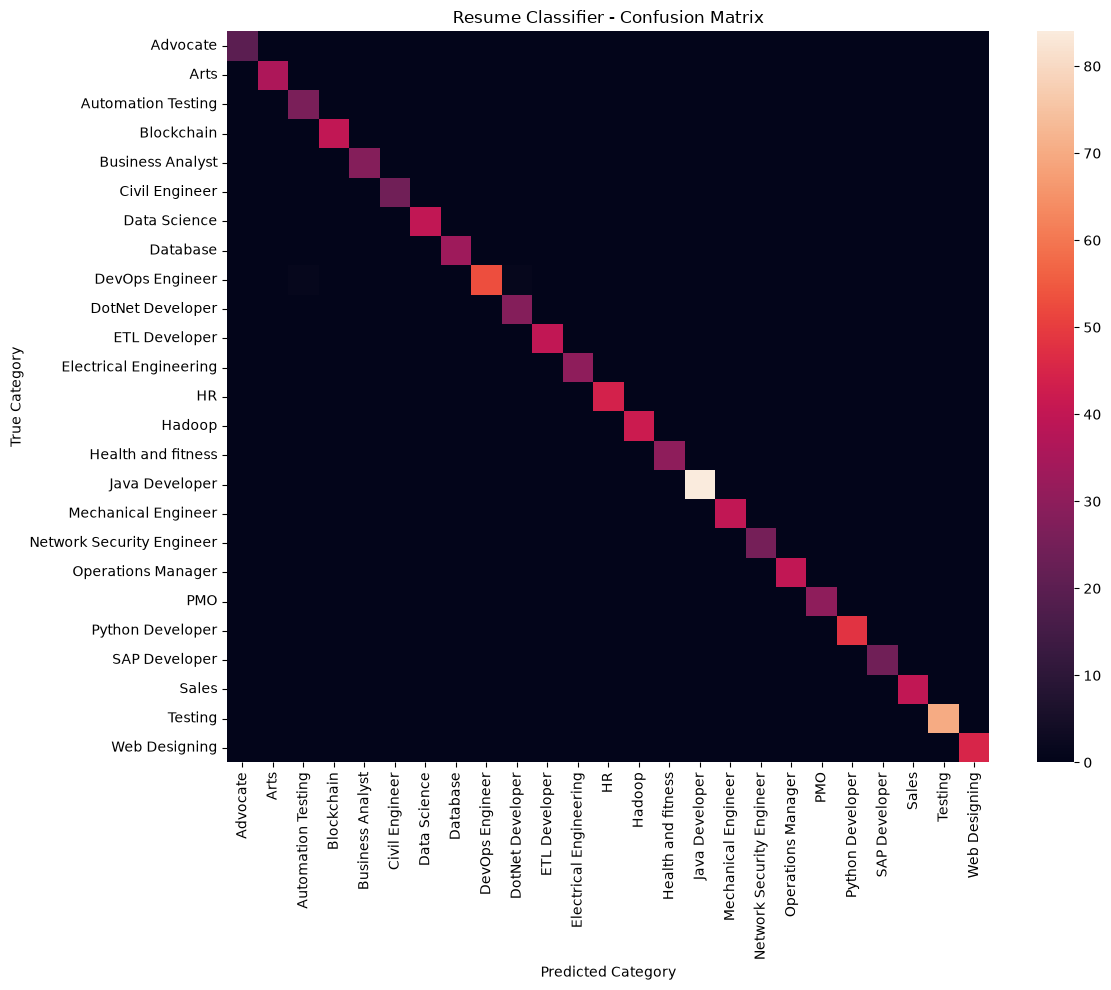

In [39]:
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(df['Category'], y_pred), 
            xticklabels=clf.classes_, yticklabels=clf.classes_, 
            annot=False)
plt.title('Resume Classifier - Confusion Matrix')
plt.ylabel('True Category')
plt.xlabel('Predicted Category')
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(FIGURES_DIR / 'confusion_matrix.png', dpi=300)
print(f"Saved confusion matrix to {FIGURES_DIR.resolve()}")
plt.show()